# Assignment #2

Write a program to enhance the given image so that the dark part on the right side of an image
brings out more details using:

1. Global histogram equalization
2. Local histogram equalization with 3 neighborhood sizes: 3x3, 7x7, and 11x11. Find the values for $k_0$, $k_1$, and $k_2$ that you think are the most suitable values.
3. Global gamma <del>collection</del> <ins>correction</ins>.
4. Local gamma <del>collection</del> <ins>correction</ins> with 2 subimage sizes by dividing the image into 2x2 and 3x3. Find
   the most suitable gamma value for each subimage.

What do you think is the best method to use for this image?


In [27]:
!uv add Pillow numpy matplotlib pandas

Resolved 45 packages in 788ms                                        
Prepared 2 packages in 536ms                                                 pandas               ------------------------------ 9.17 MiB/10.43 MiB          
Uninstalled 1 package in 1ms
Installed 2 packages in 362ms                               
 ~ 2301368-image-processing==0.1.0 (from file:///home/ptsgrn/chula/programming/2301368-image-processing)
 + pandas==3.0.5


In [7]:
IMAGE_PATH = "filament.jpg"

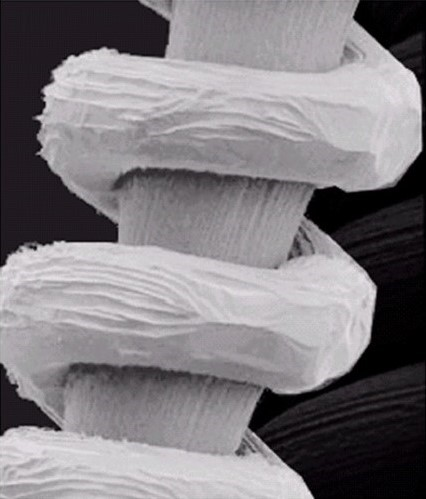

In [34]:
from PIL import Image
import numpy as np

raw_img = Image.open(IMAGE_PATH)
# OG Image
raw_img

In [ ]:
img = raw_img.convert('L')  # Convert to grayscale
img_arr = np.asarray(img)

## 1. Global histogram equalization

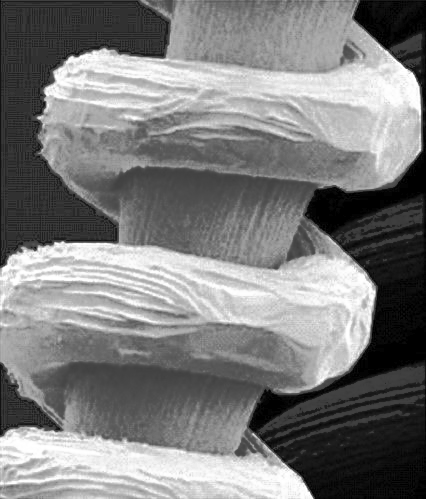

In [31]:
# Step by step implementation from https://github.com/rgkannan676/Histogram-Equalization

# This image have 256 levels of greys (0-255), so set L = 256
L = 256

# Number of pixels in the image
num_pixels = img_arr.size

# Freq of each pixel intensity
hist, _ = np.histogram(img_arr.flatten(), bins=L, range=(0, L-1))

# Probability of each pixel intensity
intensities_prob = hist / num_pixels

# Reassign pixel values based on the cumulative distribution function (CDF)
cdf = np.cumsum(intensities_prob)

# Transform the pixel values to the new values based on
# the CDF
min_cdf = np.min(cdf[np.nonzero(cdf)])  # Minimum non-zero value of CDF
new_pixel_values = np.round((cdf - min_cdf) / (1 - min_cdf) * (L - 1)).astype(np.uint8)

# Map the old pixel values to the new pixel values
equalized_img_arr = new_pixel_values[img_arr]

# Transform back to image
equalized_img = Image.fromarray(equalized_img_arr)
equalized_img

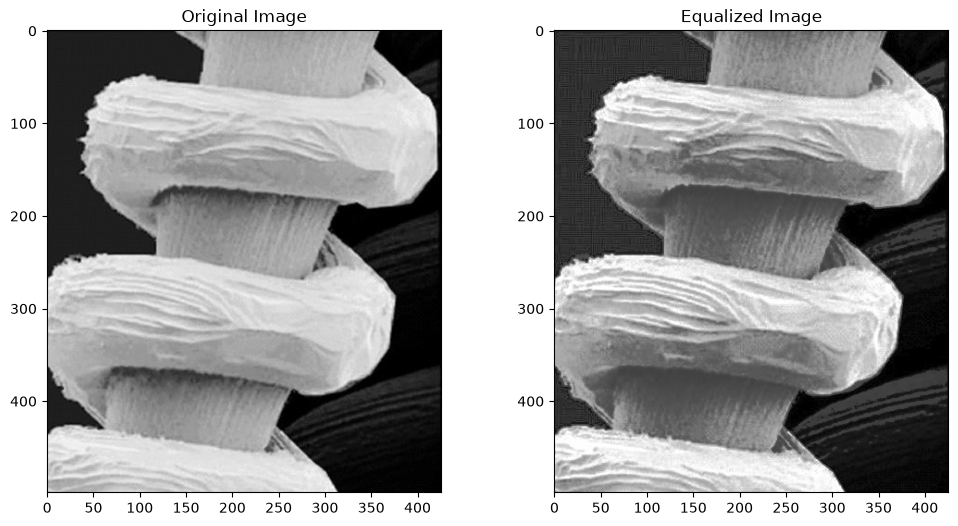

In [ ]:
# Compare the original and equalized images side by side
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Equalized Image')
plt.imshow(equalized_img, cmap='gray')

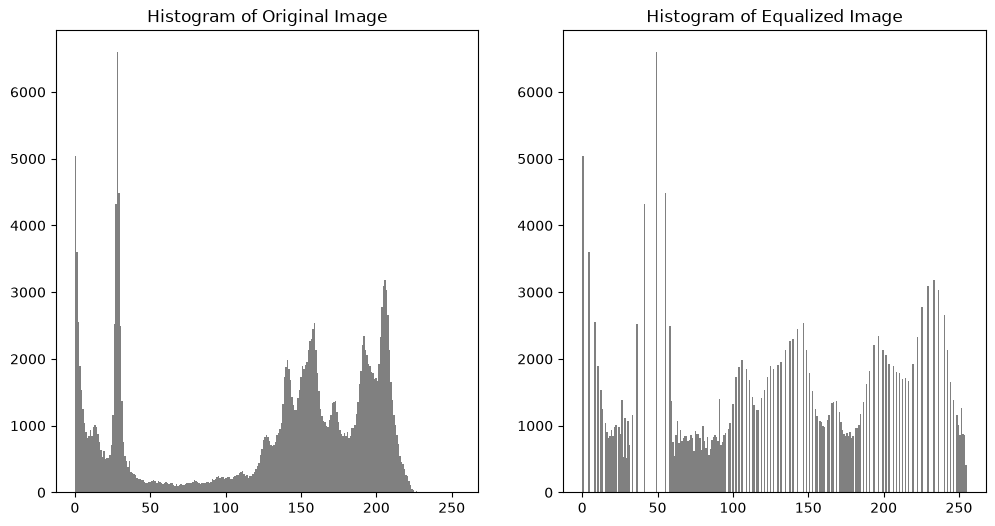

In [36]:
# Show histograms of the original and equalized images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Histogram of Original Image')
plt.hist(img_arr.flatten(), bins=L, range=(0, L-1), color='gray')
plt.subplot(1, 2, 2)
plt.title('Histogram of Equalized Image')
plt.hist(equalized_img_arr.flatten(), bins=L, range=(0, L-1), color='gray')
plt.show()

## Local histogram equalization
2. Local histogram equalization with 3 neighborhood sizes: 3x3, 7x7, and 11x11. Find the values for $k_0$, $k_1$, and $k_2$ that you think are the most suitable values.

### Conditional local histogram equalization

A pixel is enhanced only when its local neighbourhood is dark and has a useful amount of contrast:

$$m_{S_{xy}} \leq k_0m_G, \qquad k_1\sigma_G \leq \sigma_{S_{xy}} \leq k_2\sigma_G.$$

The values below ($k_0=0.8$, $k_1=0.1$, $k_2=1.5$) target darker areas while avoiding completely uniform neighbourhoods and very high-contrast edges. They are deliberately defined in one place so they can be tuned after comparing the outputs.


k0=0.8, k1=0.1, k2=1.5
3x3: 3.9% of pixels enhanced
7x7: 9.4% of pixels enhanced
11x11: 12.9% of pixels enhanced


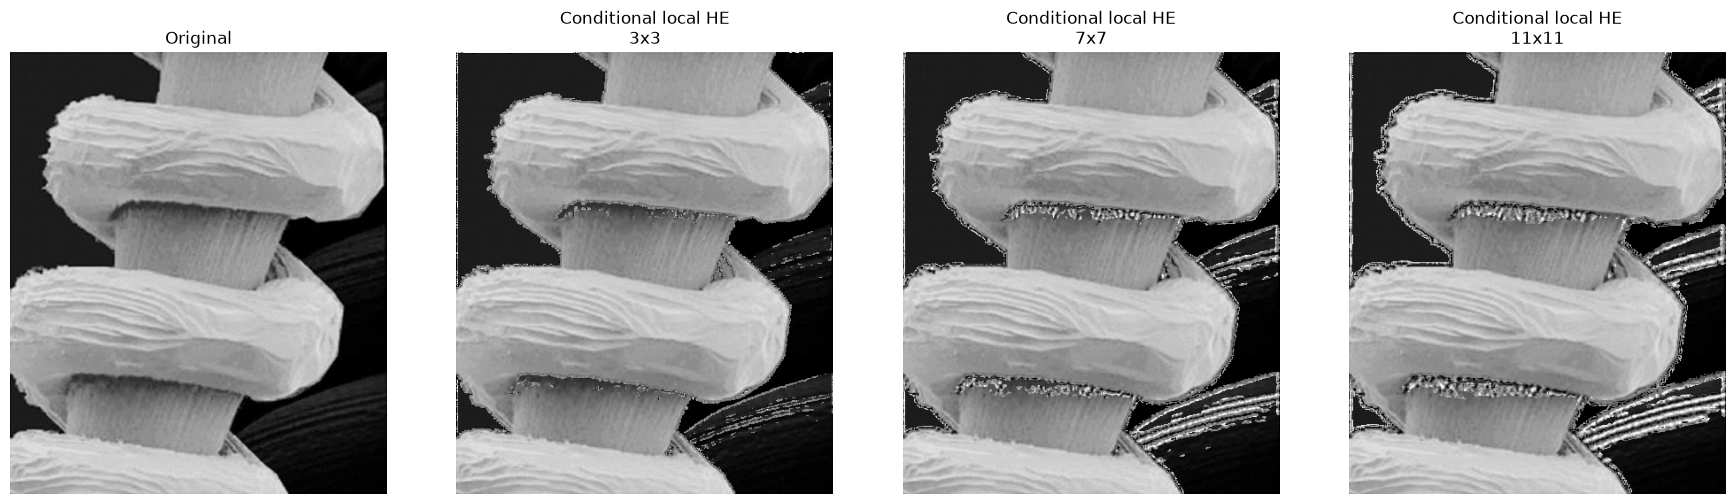

In [40]:
# Chosen conditional-local-enhancement parameters
k0, k1, k2 = 0.8, 0.1, 1.5
local_neighborhood_sizes = (3, 7, 11)

global_mean = img_arr.mean()
global_std = img_arr.std()

def conditional_local_histogram_equalization(image, window_size, k0, k1, k2):
    """Equalize only pixels whose local statistics meet the k0/k1/k2 rule."""
    pad = window_size // 2
    padded = np.pad(image, pad, mode='edge')
    windows = np.lib.stride_tricks.sliding_window_view(
        padded, (window_size, window_size)
    )

    local_mean = windows.mean(axis=(-2, -1))
    local_std = windows.std(axis=(-2, -1))
    should_enhance = (
        (local_mean <= k0 * global_mean)
        & (local_std >= k1 * global_std)
        & (local_std <= k2 * global_std)
    )

    result = image.copy()
    for row, col in zip(*np.nonzero(should_enhance)):
        window = windows[row, col]
        histogram = np.bincount(window.ravel(), minlength=256)
        cdf = histogram.cumsum()
        cdf_min = cdf[np.nonzero(cdf)[0][0]]

        # A uniform window has no contrast to enhance; retain its original value.
        if cdf_min < window.size:
            value = image[row, col]
            result[row, col] = np.round(
                (cdf[value] - cdf_min) / (window.size - cdf_min) * 255
            ).astype(np.uint8)

    return result, should_enhance

conditional_equalized = {}
enhanced_fraction = {}
for size in local_neighborhood_sizes:
    enhanced, mask = conditional_local_histogram_equalization(
        img_arr, size, k0, k1, k2
    )
    conditional_equalized[size] = enhanced
    enhanced_fraction[size] = mask.mean()

print(f'k0={k0}, k1={k1}, k2={k2}')
for size in local_neighborhood_sizes:
    print(f'{size}x{size}: {enhanced_fraction[size]:.1%} of pixels enhanced')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
for axis, size in zip(axes[1:], local_neighborhood_sizes):
    axis.imshow(conditional_equalized[size], cmap='gray', vmin=0, vmax=255)
    axis.set_title(f'Conditional local HE\n{size}x{size}')
for axis in axes:
    axis.axis('off')
plt.tight_layout()


จากผลที่ได้คิดว่าใช้ค่า 0.8, 0.1, 1.5 เป็นค่าที่เหมาะสมโดยที่ทำให้เห็นรายละเอียดของภาพส่วนที่มืดชัดเจนขึ้นโดยไม่ทำให้เกิด noise ส่วนที่เป็น uniform และ edge ที่มี contrast สูงเกินไป


## 3. Global gamma correction

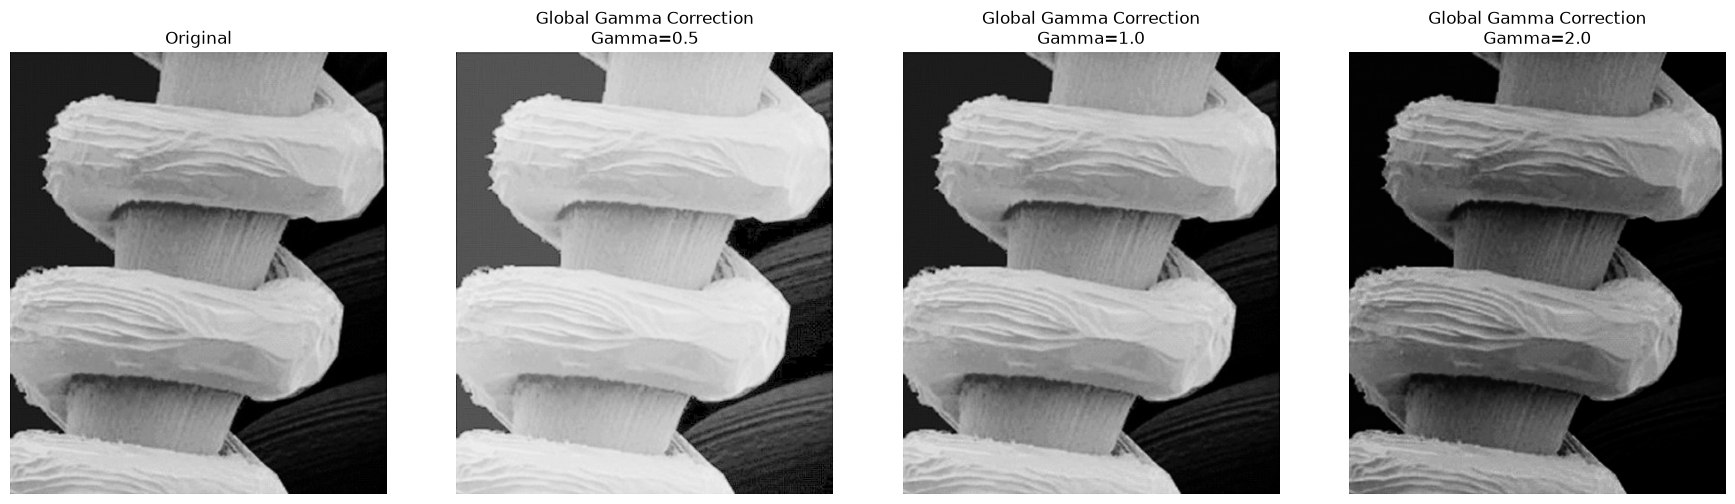

In [46]:
# Global gamma correction

def global_gamma_correction(image, gamma):
    """Apply global gamma correction to the image."""
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    return np.clip(corrected * 255, 0, 255).astype(np.uint8)
  
global_gamma_correction_values = [0.5, 1.0, 2.0]
global_gamma_corrected = {}
for gamma in global_gamma_correction_values:
    global_gamma_corrected[gamma] = global_gamma_correction(img_arr, gamma)

# Compare the original and gamma-corrected images side by side
fig, axes = plt.subplots(1, len(global_gamma_correction_values) + 1, figsize=(18, 5))
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
for axis, gamma in zip(axes[1:], global_gamma_correction_values):
    axis.imshow(global_gamma_corrected[gamma], cmap='gray', vmin=0, vmax=255)
    axis.set_title(f'Global Gamma Correction\nGamma={gamma}')
for axis in axes:
    axis.axis('off')
plt.tight_layout()

## Local gamma correction

4. Local gamma <del>collection</del> <ins>correction</ins> with 2 subimage sizes by dividing the image into 2x2 and 3x3. Find
   the most suitable gamma value for each subimage.

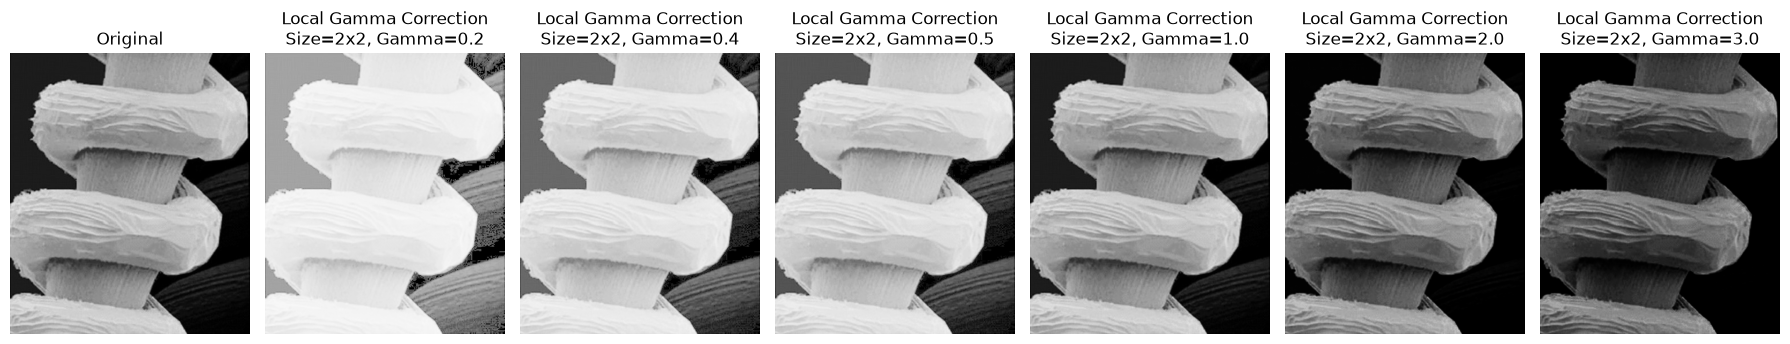

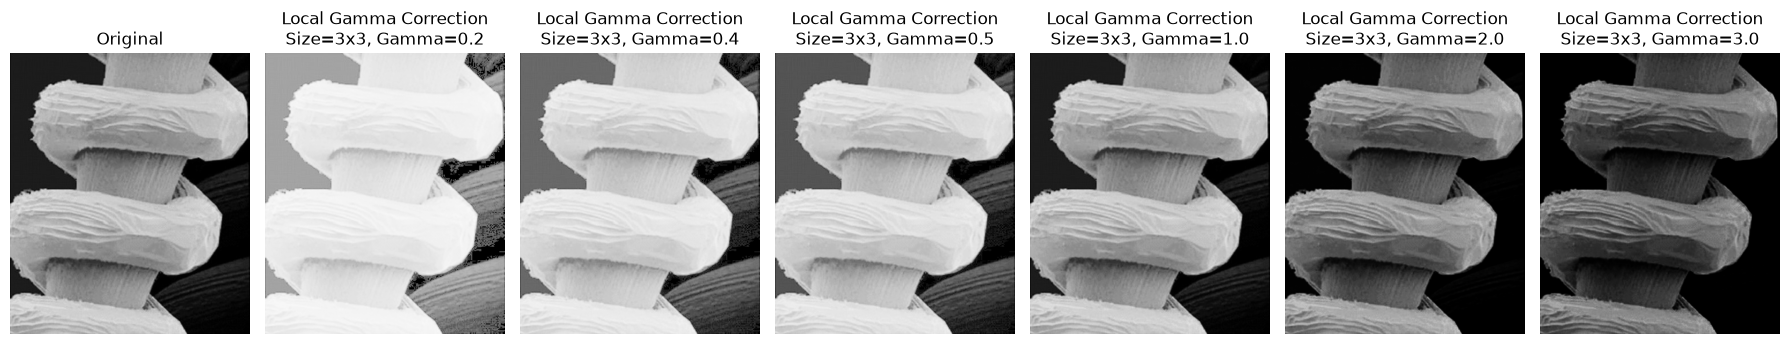

In [53]:
# Local gamma correction

def local_gamma_correction(image, subimage_size, gamma):
    """Apply local gamma correction to the image by dividing it into subimages."""
    h, w = image.shape
    corrected_image = np.zeros_like(image)
    for i in range(0, h, subimage_size):
        for j in range(0, w, subimage_size):
            subimage = image[i:i+subimage_size, j:j+subimage_size]
            corrected_subimage = global_gamma_correction(subimage, gamma)
            corrected_image[i:i+subimage_size, j:j+subimage_size] = corrected_subimage
    return corrected_image
  
subimage_sizes = [2, 3]
local_gamma_values = [0.2, 0.4,0.5, 1.0, 2.0, 3.0]
local_gamma_corrected = {}
for size in subimage_sizes:
    local_gamma_corrected[size] = {}
    for gamma in local_gamma_values:
        local_gamma_corrected[size][gamma] = local_gamma_correction(img_arr, size, gamma)
        
# Compare the original and local gamma-corrected images side by side
for size in subimage_sizes:
    fig, axes = plt.subplots(1, len(local_gamma_values) + 1, figsize=(18, 5))
    axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Original')
    for axis, gamma in zip(axes[1:], local_gamma_values):
        axis.imshow(local_gamma_corrected[size][gamma], cmap='gray', vmin=0, vmax=255)
        axis.set_title(f'Local Gamma Correction\nSize={size}x{size}, Gamma={gamma}')
    for axis in axes:
        axis.axis('off')
    plt.tight_layout()
plt.show()

Gamma value ที่เหมาะที่สุดสำหรับ subimage ขนาด 2x2 และ 3x3 คือ 0.5 ตามที่เห็นรายละเอียดของภาพส่วนที่มืดชัดเจนขึ้นโดยไม่ทำให้เกิด noise ส่วนที่เป็น uniform และ edge ที่มี contrast สูงเกินไป แต่เห็นความแตกต่างของแต่ละส่วนได้แย่กว่า Global histogram equalization และ Local histogram equalization ที่ใช้ค่า k0, k1, k2 ที่เหมาะสม

## สรุป

> What do you think is the best method to use for this image?

โดยจากผลที่ได้คิดว่าใช้ Local histogram equalization ที่ใช้ค่า k0 = 0.8, k1 = 0.1, k2 = 1.5 เป็นวิธีการที่เหมาะสมที่สุด เพราะช่วยให้เห็นรายละเอียดของขดลวดด้านหน้าและเส้นของขดลวดด้านหลังได้ชัดเจน และไม่ทำให้เปิด noise จนรบกวนการอ่านรายละเอียดของภาพมากเกินไป